In [7]:
# Minimal regression notebook (Model 9) - NO OUTLIER REMOVAL - SSP3-7.0 (bfuture)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')
print('Imports ready (SSP3-7.0 bfuture version)')


Imports ready (SSP3-7.0 bfuture version)


In [14]:
# regressionDFを読み込む
import os

# ファイルパス
base_dir = r'C:\Users\xyz19\OneDrive\デスクトップ\予測モデルデータセット'
file_path = os.path.join(base_dir, 'regression_df_20260112_233447.xlsx')

# データを読み込む
print("データを読み込んでいます...")
regression_df = pd.read_excel(file_path)

print("✓ データの読み込みが完了しました。")
print(f"データ形状: {regressionDF.shape}")

データを読み込んでいます...
✓ データの読み込みが完了しました。
データ形状: (16388, 8)


In [15]:
# Train Model 9 (GradientBoosting) - NO OUTLIER REMOVAL
# regression_df をそのまま使用（外れ値除去なし）
if regression_df.empty:
    raise RuntimeError('No data available')

# 欠損値のみ除去
regression_clean = regression_df.dropna().copy()
print('After dropna only (no outlier removal):', regression_clean.shape)

# Fix category universe for reproducibility
regression_clean['Area'] = pd.Categorical(regression_clean['Area'], categories=sorted(list(set(regression_clean['Area']))))
regression_clean['Item'] = pd.Categorical(regression_clean['Item'], categories=['Rice','Wheat','Maize (corn)'])

X_base = regression_clean[['Year','SPEI','GSL','Hurs','TXX']].copy()
X = pd.concat([X_base, pd.get_dummies(regression_clean[['Area','Item']], prefix=['Area','Crop'], drop_first=True)], axis=1)
y = regression_clean['Yield']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print('Model 9 (NO OUTLIER REMOVAL): R2={:.4f}, RMSE={:.2f}, MAE={:.2f}'.format(r2, rmse, mae))


After dropna only (no outlier removal): (16388, 8)
Model 9 (NO OUTLIER REMOVAL): R2=0.9060, RMSE=773.72, MAE=497.79


In [18]:
# 全データを訓練とテストに分けて30回実行し、R²を計算
# モデル9（外れ値除去なし）のパラメーターを使用

if 'regression_clean' not in globals() or regression_clean.empty:
    raise RuntimeError('regression_clean が未定義です。先にデータ準備セルを実行してください。')

print('=== 全データを訓練とテストに分けて30回実行 ===\n')

# データの準備
data_for_split = regression_clean.copy()

# カテゴリの固定
data_for_split['Area'] = pd.Categorical(data_for_split['Area'], categories=sorted(data_for_split['Area'].unique()))
data_for_split['Item'] = pd.Categorical(data_for_split['Item'], categories=['Rice','Wheat','Maize (corn)'])

# 特徴量の準備
X_base_split = data_for_split[['Year','SPEI','GSL','Hurs','TXX']].copy()
X_full = pd.concat([
    X_base_split,
    pd.get_dummies(data_for_split[['Area','Item']], prefix=['Area','Crop'], drop_first=True)
], axis=1)
y_full = data_for_split['Yield']

print(f'全データ数: {len(X_full)}サンプル')
print(f'特徴量数: {X_full.shape[1]}個\n')

# 30回のランダム分割でR²を計算
n_repeats = 10
r2_list = []
rmse_list = []
mae_list = []
train_sizes = []
test_sizes = []

print('10回のランダム分割を実行中...')
for seed in range(n_repeats):
    # ランダムに訓練とテストに分割（test_size=0.2）
    X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
        X_full, y_full, test_size=0.2, random_state=seed, shuffle=True
    )
    
    train_sizes.append(len(X_train_30))
    test_sizes.append(len(X_test_30))
    
    # モデル9のパラメーターで学習
    gb_30 = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=7,
        learning_rate=0.1,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=seed
    )
    
    gb_30.fit(X_train_30, y_train_30)
    y_pred_30 = gb_30.predict(X_test_30)
    
    # 評価指標
    r2_30 = r2_score(y_test_30, y_pred_30)
    rmse_30 = np.sqrt(mean_squared_error(y_test_30, y_pred_30))
    mae_30 = mean_absolute_error(y_test_30, y_pred_30)
    
    r2_list.append(r2_30)
    rmse_list.append(rmse_30)
    mae_list.append(mae_30)
    
    if (seed + 1) % 5 == 0:
        print(f'  {seed + 1}/{n_repeats} 完了')

# 結果をまとめる
results_30 = pd.DataFrame({
    'Run': range(1, n_repeats + 1),
    'Train_Size': train_sizes,
    'Test_Size': test_sizes,
    'R2': r2_list,
    'RMSE': rmse_list,
    'MAE': mae_list
})

print('\n=== 30回実行の結果 ===')
print(f'R²  : 平均={np.mean(r2_list):.4f}, 標準偏差={np.std(r2_list):.4f}, 最小={np.min(r2_list):.4f}, 最大={np.max(r2_list):.4f}')
print(f'RMSE: 平均={np.mean(rmse_list):.2f}, 標準偏差={np.std(rmse_list):.2f}, 最小={np.min(rmse_list):.2f}, 最大={np.max(rmse_list):.2f}')
print(f'MAE : 平均={np.mean(mae_list):.2f}, 標準偏差={np.std(mae_list):.2f}, 最小={np.min(mae_list):.2f}, 最大={np.max(mae_list):.2f}')

# 結果を表示
print('\n=== 詳細結果（30回） ===')
display(results_30)

# 可視化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. R²の分布
axes[0, 0].hist(r2_list, bins=15, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].axvline(np.mean(r2_list), color='red', linestyle='--', linewidth=2, label=f'平均: {np.mean(r2_list):.4f}')
axes[0, 0].set_xlabel('R²', fontsize=11)
axes[0, 0].set_ylabel('頻度', fontsize=11)
axes[0, 0].set_title('R²の分布（30回実行）', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. R²の時系列（実行順）
axes[0, 1].plot(range(1, n_repeats + 1), r2_list, 'o-', linewidth=1, markersize=4, color='blue', alpha=0.7)
axes[0, 1].axhline(np.mean(r2_list), color='red', linestyle='--', linewidth=2, label=f'平均: {np.mean(r2_list):.4f}')
axes[0, 1].set_xlabel('実行回数', fontsize=11)
axes[0, 1].set_ylabel('R²', fontsize=11)
axes[0, 1].set_title('R²の推移（30回実行）', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. RMSEの分布
axes[1, 0].hist(rmse_list, bins=15, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].axvline(np.mean(rmse_list), color='red', linestyle='--', linewidth=2, label=f'平均: {np.mean(rmse_list):.2f}')
axes[1, 0].set_xlabel('RMSE', fontsize=11)
axes[1, 0].set_ylabel('頻度', fontsize=11)
axes[1, 0].set_title('RMSEの分布（30回実行）', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. R² vs RMSE
axes[1, 1].scatter(r2_list, rmse_list, alpha=0.6, s=50, color='green')
axes[1, 1].set_xlabel('R²', fontsize=11)
axes[1, 1].set_ylabel('RMSE', fontsize=11)
axes[1, 1].set_title('R² vs RMSE（30回実行）', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n=== 統計的サマリー ===')
print(f'R²の95%信頼区間: [{np.percentile(r2_list, 2.5):.4f}, {np.percentile(r2_list, 97.5):.4f}]')
print(f'R²の中央値: {np.median(r2_list):.4f}')
print(f'R²の四分位範囲: Q1={np.percentile(r2_list, 25):.4f}, Q3={np.percentile(r2_list, 75):.4f}')

=== 全データを訓練とテストに分けて30回実行 ===

全データ数: 16388サンプル
特徴量数: 162個

10回のランダム分割を実行中...
  5/10 完了
  10/10 完了

=== 30回実行の結果 ===
R²  : 平均=0.8959, 標準偏差=0.0075, 最小=0.8842, 最大=0.9094
RMSE: 平均=747.89, 標準偏差=40.64, 最小=693.69, 最大=838.34
MAE : 平均=499.99, 標準偏差=11.82, 最小=478.81, 最大=525.23

=== 詳細結果（30回） ===


,Run,Train_Size,Test_Size,R2,RMSE,MAE
0,1,13110,3278,0.899558,728.703168,496.025112
1,2,13110,3278,0.896942,699.181574,488.714339
2,3,13110,3278,0.902441,749.498689,511.055679
3,4,13110,3278,0.909372,693.692583,478.808367
4,5,13110,3278,0.893855,737.736158,504.298763
5,6,13110,3278,0.898098,738.409365,497.925674
6,7,13110,3278,0.887891,778.581106,502.278662
7,8,13110,3278,0.886319,783.279475,495.754729
8,9,13110,3278,0.884207,838.337885,525.229643
9,10,13110,3278,0.900811,731.504482,499.762129


: 

=== 特徴量重要度（Top 20） ===
                              feature  importance
                                  GSL    0.162427
                                 Year    0.152540
                           Crop_Wheat    0.126929
                    Crop_Maize (corn)    0.107122
                                 Hurs    0.095235
            Area_United Arab Emirates    0.046796
                          Area_Israel    0.031498
                          Area_Kuwait    0.028488
                                  TXX    0.025699
Area_Saint Vincent and the Grenadines    0.021197
                           Area_Qatar    0.019402
                          Area_Bhutan    0.012943
                       Area_Australia    0.010820
                                 SPEI    0.005915
                          Area_Greece    0.005801
                       Area_Mauritius    0.005795
        Area_United States of America    0.005569
                          Area_Zambia    0.005497
                     Area_S

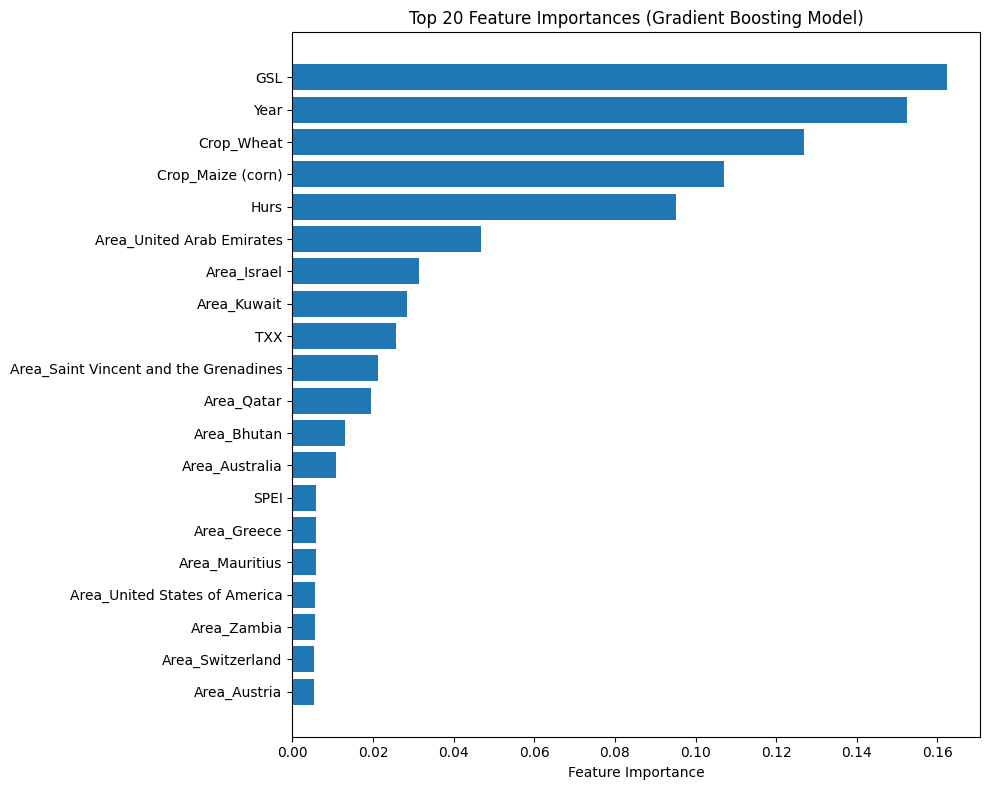


=== 連続特徴量の重要度 ===
feature  importance
    GSL    0.162427
   Year    0.152540
   Hurs    0.095235
    TXX    0.025699
   SPEI    0.005915


In [20]:
# 特徴量重要度の表示
import matplotlib.pyplot as plt

if 'gb' in globals() and hasattr(gb, 'feature_importances_'):
    # 特徴量重要度を取得
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': gb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print('=== 特徴量重要度（Top 20） ===')
    print(feature_importance.head(20).to_string(index=False))
    
    # 可視化（Top 20）
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'].values)
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Feature Importances (Gradient Boosting Model)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # 連続特徴量（Year, SPEI, GSL, Hurs, TXX）の重要度を個別に表示
    continuous_features = ['Year', 'SPEI', 'GSL', 'Hurs', 'TXX']
    continuous_importance = feature_importance[feature_importance['feature'].isin(continuous_features)]
    print('\n=== 連続特徴量の重要度 ===')
    print(continuous_importance.to_string(index=False))
else:
    print('モデルがまだ学習されていません。先にCell 7を実行してください。')


In [1]:
# ハイパーパラメーターチューニング（GridSearchCV）
from sklearn.model_selection import GridSearchCV

# データの準備（regression_cleanが定義されていることを確認）
if 'regression_clean' not in globals() or regression_clean.empty:
    raise RuntimeError('regression_clean が未定義です。先にデータ準備セルを実行してください。')

# カテゴリの固定
data_for_grid = regression_clean.copy()
data_for_grid['Area'] = pd.Categorical(data_for_grid['Area'], categories=sorted(data_for_grid['Area'].unique()))
data_for_grid['Item'] = pd.Categorical(data_for_grid['Item'], categories=['Rice','Wheat','Maize (corn)'])

# 特徴量の準備
X_base_grid = data_for_grid[['Year','SPEI','GSL','Hurs','TXX']].copy()
X_grid = pd.concat([
    X_base_grid,
    pd.get_dummies(data_for_grid[['Area','Item']], prefix=['Area','Crop'], drop_first=True)
], axis=1)
y_grid = data_for_grid['Yield']

# 訓練データとテストデータに分割
X_train_grid, X_test_grid, y_train_grid, y_test_grid = train_test_split(
    X_grid, y_grid, test_size=0.2, random_state=42, shuffle=True
)

print(f'訓練データ数: {len(X_train_grid)}')
print(f'テストデータ数: {len(X_test_grid)}')
print(f'特徴量数: {X_grid.shape[1]}個\n')

# ハイパーパラメータのグリッドを定義
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 7, 8, 9],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'min_samples_split': [5, 7, 9],
    'min_samples_leaf': [2, 3, 4]
}

print("="*60)
print("GridSearchCVでハイパーパラメーターチューニングを開始...")
print("="*60)
total_combinations = (len(param_grid['n_estimators']) * 
                     len(param_grid['max_depth']) * 
                     len(param_grid['learning_rate']) * 
                     len(param_grid['min_samples_split']) * 
                     len(param_grid['min_samples_leaf']))
print(f"探索するパラメータの組み合わせ数: {total_combinations}")
print(f"3-fold CV × {total_combinations} = {total_combinations * 3} 回のモデル訓練が必要です\n")

# GridSearchCVを実行
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # RMSEを最小化
    cv=3,  # 3-fold cross-validation
    n_jobs=-1,
    verbose=1
)

print("チューニングを実行中...")
grid_search.fit(X_train_grid, y_train_grid)

# 最適なパラメータを表示
print("\n" + "="*60)
print("最適なハイパーパラメータ:")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n最良のCVスコア (負のMSE): {grid_search.best_score_:.4f}")
print(f"最良のCVスコア (RMSE): {np.sqrt(-grid_search.best_score_):.4f}")

# 最適なモデルでテストデータを評価
best_gb = grid_search.best_estimator_
y_pred_grid = best_gb.predict(X_test_grid)

r2_grid = r2_score(y_test_grid, y_pred_grid)
rmse_grid = np.sqrt(mean_squared_error(y_test_grid, y_pred_grid))
mae_grid = mean_absolute_error(y_test_grid, y_pred_grid)

print("\n" + "="*60)
print("最適パラメータでのテストデータ性能:")
print("="*60)
print(f"R²: {r2_grid:.4f}")
print(f"RMSE: {rmse_grid:.2f}")
print(f"MAE: {mae_grid:.2f}")

# 最適なモデルをgbとして保存（後続のセルで使用可能）
gb = best_gb
print("\n最適なモデルを 'gb' として保存しました。")

# 上位20モデルの結果を表示（RMSEとR²の両方）
print("\n" + "="*60)
print("上位20モデルの結果:")
print("="*60)

# tqdmをインポート（進捗表示用）
try:
    from tqdm import tqdm
except ImportError:
    print("tqdmをインストール中...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tqdm", "-q"])
    from tqdm import tqdm

# cv_results_から結果を取得
results_df = pd.DataFrame(grid_search.cv_results_)

# スコア（負のMSE）をRMSEに変換
results_df['RMSE'] = np.sqrt(-results_df['mean_test_score'])
results_df['RMSE_std'] = np.sqrt(results_df['std_test_score'])

# パラメータ列を取得
param_cols = [col for col in results_df.columns if col.startswith('param_')]

# まずRMSEで上位20を選択
top20_rmse_indices = results_df.nsmallest(20, 'RMSE').index

# 上位20モデルについてR²を計算
print("上位20モデル（RMSE順）のR²を計算中...")
r2_scores_rmse = []
for idx in tqdm(top20_rmse_indices, desc="R²計算中 (上位20/RMSE順)", ncols=80):
    row = results_df.loc[idx]
    # パラメータを取得
    params = {col.replace('param_', ''): row[col] for col in param_cols}
    
    # モデルを作成して訓練
    model = GradientBoostingRegressor(random_state=42, **params)
    model.fit(X_train_grid, y_train_grid)
    
    # 予測してR²を計算
    y_pred_temp = model.predict(X_train_grid)
    r2_temp = r2_score(y_train_grid, y_pred_temp)
    r2_scores_rmse.append(r2_temp)

# 上位20（RMSE順）の結果
top20_rmse = results_df.loc[top20_rmse_indices, 
    param_cols + ['mean_test_score', 'std_test_score', 'RMSE', 'RMSE_std']
].copy()
top20_rmse['R2'] = r2_scores_rmse

# すべてのモデルについてR²を計算してから上位20を選択
print("\nすべてのモデルのR²を計算中...")
r2_scores_all = []
for idx, row in tqdm(results_df.iterrows(), total=len(results_df), desc="R²計算中 (全モデル)", ncols=80):
    # パラメータを取得
    params = {col.replace('param_', ''): row[col] for col in param_cols}
    
    # モデルを作成して訓練
    model = GradientBoostingRegressor(random_state=42, **params)
    model.fit(X_train_grid, y_train_grid)
    
    # 予測してR²を計算
    y_pred_temp = model.predict(X_train_grid)
    r2_temp = r2_score(y_train_grid, y_pred_temp)
    r2_scores_all.append(r2_temp)

results_df['R2'] = r2_scores_all

# 上位20を選択（R²が大きい順）
top20_r2_indices = results_df.nlargest(20, 'R2').index
top20_r2 = results_df.loc[top20_r2_indices,
    param_cols + ['mean_test_score', 'std_test_score', 'RMSE', 'RMSE_std', 'R2']
].copy()

# 列名を整理
for df in [top20_rmse, top20_r2]:
    df.rename(columns={
        'mean_test_score': 'mean_test_score(neg_MSE)',
        'std_test_score': 'std_test_score(neg_MSE)'
    }, inplace=True)
    
    # パラメータ列名から'param_'を削除
    df.columns = [col.replace('param_', '') if col.startswith('param_') else col for col in df.columns]
    
    # 順位を追加
    df.insert(0, 'Rank', range(1, len(df) + 1))

print(f"\n上位20モデル（RMSEが小さい順）:")
print(top20_rmse.to_string(index=False))

print(f"\n上位20モデル（R²が大きい順）:")
print(top20_r2.to_string(index=False))

# 上位20モデルの可視化
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 上位20モデルのRMSE（RMSE順）
axes[0, 0].barh(range(len(top20_rmse)), top20_rmse['RMSE'].values)
axes[0, 0].set_yticks(range(len(top20_rmse)))
axes[0, 0].set_yticklabels([f"Rank {i+1}" for i in range(len(top20_rmse))])
axes[0, 0].set_xlabel('RMSE (Cross-Validation)')
axes[0, 0].set_title('Top 20 Models - RMSE (sorted by RMSE)')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. 上位20モデルのR²（R²順）
axes[0, 1].barh(range(len(top20_r2)), top20_r2['R2'].values, color='green')
axes[0, 1].set_yticks(range(len(top20_r2)))
axes[0, 1].set_yticklabels([f"Rank {i+1}" for i in range(len(top20_r2))])
axes[0, 1].set_xlabel('R²')
axes[0, 1].set_title('Top 20 Models - R² (sorted by R²)')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. 上位20モデルのパラメータ比較（RMSE順）
param_to_plot = ['n_estimators', 'max_depth', 'learning_rate']
x_pos = np.arange(len(top20_rmse))
width = 0.25

for i, param in enumerate(param_to_plot):
    if param in top20_rmse.columns:
        axes[1, 0].bar(x_pos + i*width, top20_rmse[param].values, width, label=param)

axes[1, 0].set_xlabel('Rank (by RMSE)')
axes[1, 0].set_ylabel('Parameter Value')
axes[1, 0].set_title('Top 20 Models - Key Parameters (sorted by RMSE)')
axes[1, 0].set_xticks(x_pos + width)
axes[1, 0].set_xticklabels([f"{i+1}" for i in range(len(top20_rmse))])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. 上位20モデルのパラメータ比較（R²順）
for i, param in enumerate(param_to_plot):
    if param in top20_r2.columns:
        axes[1, 1].bar(x_pos + i*width, top20_r2[param].values, width, label=param)

axes[1, 1].set_xlabel('Rank (by R²)')
axes[1, 1].set_ylabel('Parameter Value')
axes[1, 1].set_title('Top 20 Models - Key Parameters (sorted by R²)')
axes[1, 1].set_xticks(x_pos + width)
axes[1, 1].set_xticklabels([f"{i+1}" for i in range(len(top20_r2))])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

RuntimeError: regression_clean が未定義です。先にデータ準備セルを実行してください。